# Zeitlin model with constraints

This notebook is a demonstration of how to use `quflow.constraints' module

In [1]:
# For non-interactive plots:
%matplotlib inline

# Looks better on macbooks
%config InlineBackend.figure_format = 'retina' 

import numpy as np
import quflow as qf

In [2]:
# Modules to load
import matplotlib.pyplot as plt
from quflow.constraints import *
from quflow.earth_coastlines_adaptive import earth_coastlines

# Save cell for runfile 
cell1 = In[-1]

##### Set the functions defining the islands and their level sets. The projection restricts vorticity to the domain and sets its trace to zero. Then construct a plotter adapted to the domain.

In [3]:
N = 512

f1 = qf.dynamics.blob(N, [0, 2, 1],0.1) # Island 1 
f2 = qf.dynamics.blob(N, [0, -2, -1],0.1) # Island 2 
f3 = qf.dynamics.blob(N, [0, -6, 1],0.1) # Island 2
functions =  [f1,f2 +f3]
level_sets = [0.008, 0.008]  # Choose coastlines
#functions, level_sets = earth_coastlines(N,rotate=True) # Order: [Antarctica, connected mainland]; levels: [0.0, 0.0].

# Make conatraint function
Fc, closest_eigenvalues = constraint_matrix(functions,level_sets) # Construct the constraint matrix
# Make plotter with contours
constraint_animation_args = [functions, level_sets]
cplot = plotter(functions,level_sets, N=N)

# Save cell for runfile
cell2 = In[-1]

##### Inspect the domain

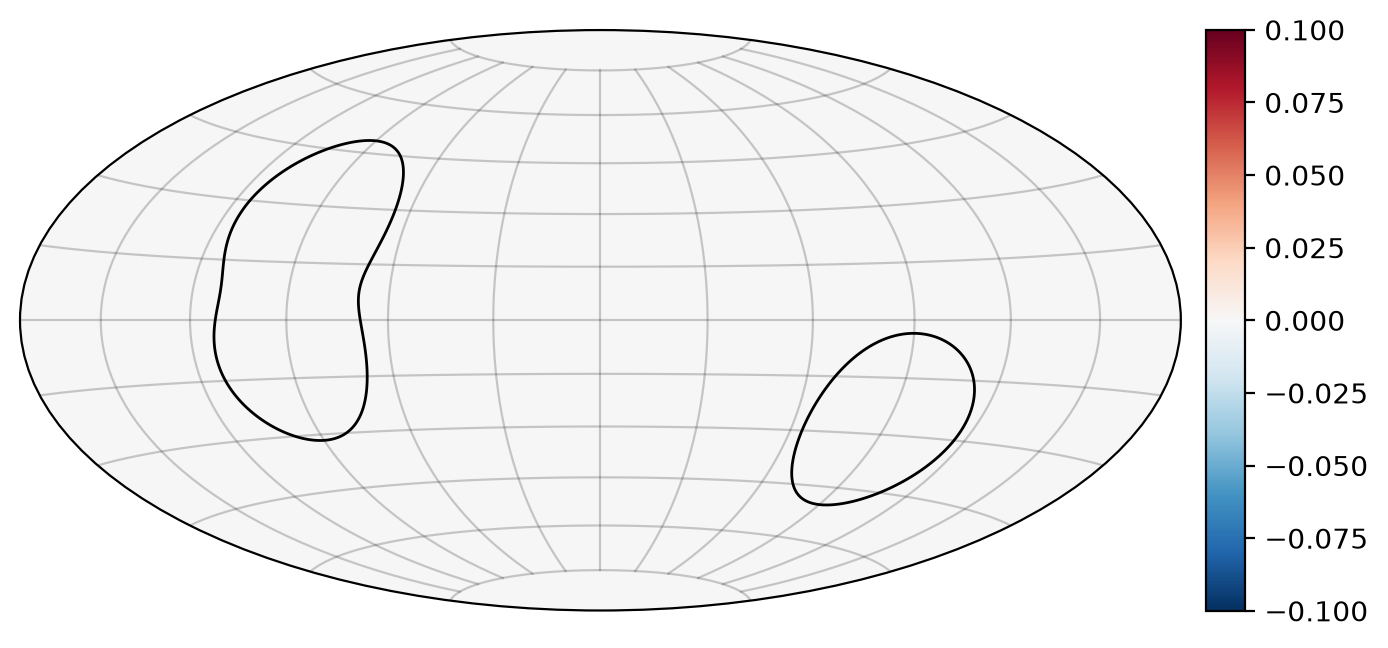

In [4]:
cplot(qf.shr2mat(np.zeros(N**2)),colorbar=True)

##### Make the constraint function $F_c$, and inspect it. 

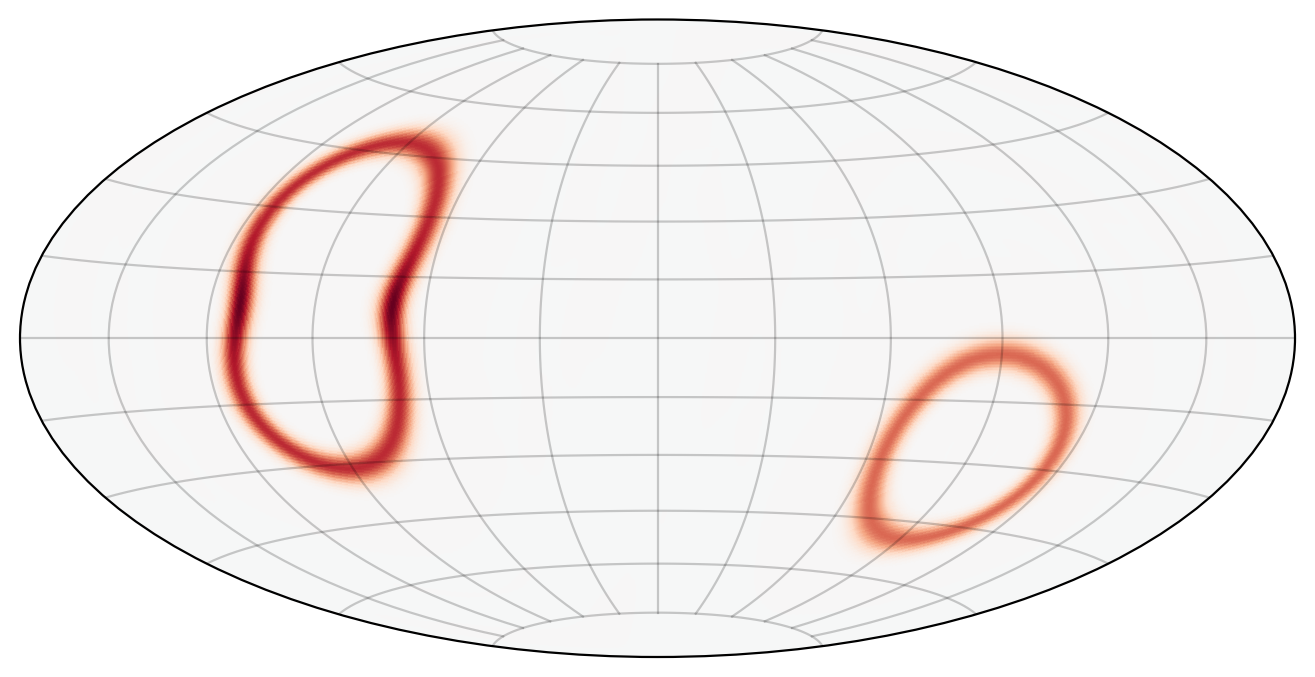

In [5]:
qf.plot(Fc)

##### Make the constraint solver

In [6]:
import scipy


eigenvals, eigenvects = scipy.linalg.eigh((-1j)*Fc)
eigenvectors =eigenvects[:,-2:]
eigenvectors
solver = CommutatorPoissonSolver(eigenvectors=eigenvectors)
#qf.norm_L2((np.outer(1j*eigenvectors[:,0],eigenvectors[:,0].conj().T)) + 2*np.outer(1j*eigenvectors[:,1], eigenvectors[:,1].conj().T) -Fc,)

CommutatorPoissonSolver: retained 2042 constraint rows.


The cell above can be done only on a cluster instead.

In [7]:
cell3 = "solver = CommutatorPoissonSolver( Fc, num_active_eigenvalues = len(functions),  rng=np.random.default_rng(seed=42))"

##### Choose some circulations, and make an intial vorticity.

In [8]:
# Create circulations function

circulations = [0.0, -0.0]

# We can also, if we want, enforce that the total circulation is zero.
zero_total_circulation = False
if zero_total_circulation:
    sum_circulation_values = sum(circulations)
    for i in range(len(circulations)):
        circulations[i] = circulations[i] - (sum_circulation_values/len(circulations))
circulation_functions = [largest_eigenvector(f) for f in functions]

sum_circulation_functions= sum([ g * f for (g, f) in zip(circulations,circulation_functions)])

# Make initial data compatible with circulations

omega0 = qf.analysis.random_shr(lmax=11, s=0.0, gamma=0., seed=42)
W0 = qf.shr2mat(omega0, N=N) 

# Project the initial vorticity, and set compatible trace
W0_proj = project_domain(W0, functions, level_sets, prescribed_trace=circulations)


# Save cell for runfile
cell4 = In[-1]

##### Make solver which adds circulation terms

In [9]:
def solve_function(W):
    return solver.solve(W - sum_circulation_functions)


# Save cell for runfile
cell5 = In[-1]

##### Add logger functions

In [10]:
# For example, define logger functions
# (exactly these loggers are also defined in `qf.physics.energy_euler` and `qf.physics.enstrophy`)
def energy(W):
    P = qf.solve_poisson(W)
    return -qf.geometry.inner_L2(W, P)

def enstrophy(W):
    return qf.geometry.inner_L2(W, W)

def eigenvalues_normal(W):
    eigenvals, eigenvects = scipy.linalg.eig(W)
    projection_norms = [qf.norm_L2(project_domain( np.outer(eigenvects[:,i], eigenvects[:,i].conj().T),functions,level_sets)) for i in range(len(eigenvals))]
    number_interior = 0
    for value in projection_norms:
        if np.isclose(value,0,atol=0.001):
            number_interior +=1
    return number_interior



# For example, define a new Poisson solver here:
def solve_poisson_special(W):
    raise NotImplementedError()

# Save cell for runfile
cell6 = In[-1]

##### Make simulation object

In [11]:
# Simulation
filename = f"constraint_sim_N_{N}.hdf5"
simtime = 10
inner_time = 0.2
dt = 0.25 * qf.hbar(N)
W0 = W0_proj

# Callback data object
mysim = qf.QuSimulation(filename, overwrite=True, state=W0, 
                        loggers={'energy':qf.physics.energy_euler, 'enstrophy':qf.physics.enstrophy})

# Set parameters for `solve` function. This is VERY convenient when moving a 
# simulation from your computer to the cluster.
mysim['dt'] = dt
mysim['simtime'] = simtime
mysim['inner_time'] = inner_time
mysim['integrator'] = qf.isomp
#mysim['hamiltonian'] = constraints_solver.solve

##### Write cells to runfile

In [12]:
cells =[cell1,cell2,cell3,cell4,cell5,cell6]

prerun =""

for cell in cells:
    prerun += "\n" + cell

# Short code which deletes lines that contain cell fro prerun
prerun= "\n".join([line for line in prerun.splitlines() if "cell" not in line])

mysim["prerun"] = prerun

In [13]:
qf.create_runfile(mysim, runfilename="mysim_runfile.py")

##### Make scripts to run on Orion HPC

In [14]:
%%writefile run_orion.sh
#!/bin/bash
#SBATCH --mem=64G
#SBATCH --partition=orion
#SBATCH --time=7-00:00:00
#SBATCH --job-name=quflow-sim
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=4
#SBATCH --mail-user=andreas.myklebust@nmbu.no
#SBATCH --mail-type=END,FAIL
#SBATCH --account=realtek_stipandreasmyklebust




echo "=== Ran on $(hostname) at $(date) ==="
echo "CPU cores visible: $(nproc)"
free -h

# Run script for starting simulations on Vera

basedir=$(dirname "$0")
if command -v module &> /dev/null
then
    # if [[ $SLURM_NTASKS =~ ^[0-9]+$ ]]; then
    #     export OMP_NUM_THREADS=$((SLURM_NTASKS*SLURM_CPUS_PER_TASK))
    # fi
    echo "Max number of threads: $OMP_NUM_THREADS"

    echo "Loading modules ..."

    # Current 
    #module load FlexiBLAS/3.4.5-GCC-14.3.0
    #module load SciPy-bundle/2025.07-gfbf-2025b
    #module load FFmpeg/7.1.2-GCCcore-14.3.0
    #module load FFTW/3.3.10-GCC-14.3.0
    #module load tqdm/4.67.1-GCCcore-14.3.0
    #module load matplotlib/3.10.5-gfbf-2025b
    #module load virtualenv/20.32.0-GCCcore-14.3.0
    #module load numba/0.62.0-foss-2025b
    #module load h5py/3.14.0-foss-2025b

    # Microforge
    module load Miniforge3
    export MAMBA_ROOT_PREFIX=~/.micromamba_root
    eval "$(micromamba shell hook --shell bash)"
    micromamba activate ZeitlinMamba


    if [ -d ${HOME}/quflow-addons ]; then 
        echo "Environment ~/quflow-addons exists, activating it ..."
        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate
        echo "...done"
    else
        # Create virtualenv. You can change "quflow-addons-amd" to some other name
        # if you need to keep several environments.
        echo "Creating virtual environment ~/quflow-addons ..." 
        virtualenv --system-site-packages ${HOME}/quflow-addons
        echo "...done"

        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate

        # Install quflow as an editable module (located in the home folder)
        if [ -d ${HOME}/quflow ]; then
            echo "Local quflow directory ~/quflow exists"

            # Install quflow to the virtualenv
            echo "Pip-installing editable quflow into ~/quflow-addons ..."
            pip install -e ${HOME}/quflow
            echo "...done"

        else
            # Install non-editable (regular) quflow
            echo "Pip-installing non-editable quflow into ~/quflow-addons ..."
            pip install https://github.com/andrmykl/quflow/archive/master.zip
            echo "...done"
        fi
    fi
fi

echo "Running command: python -u $@"
start=`date +%s`
python -u "$@"
end=`date +%s`
runtime=$((end-start))
echo "...finished in $runtime seconds"

Overwriting run_orion.sh


##### Start the simulation on Orion

Now login via `ssh` to Orion. Change to the directory where you uploaded your files. Now, to schedule a `quflow` run on Orion, execute the following command:
```
sbatch -c 8 run_orion.sh mysim_runfile.py --simtime 100 -f mysim_N_512.hdf5
```
Here, the option `--simtime` specifies the simulation time for the run (added to the last output time). One can also use the option `--endtime` which sets the absolute end simulation time. The option `-c` specifies the number of cores to use. A good rule for the number of cores is as follows

| N | cores |
|---|-------|
|256 | 4 |
|512 | 8 |
|1024 | 16 |
|2048 | 32 |

##### Run the simulation on the computer

In [15]:
import numba

numba.set_num_threads(1) # Find out what is fastest on your computer

# Run simulation directly from QuSimulation object
qf.solve(mysim,hamiltonian=solve_function ,simtime=10)

# Plot average number of iterations over time.
# This is a good check that everything went well 
# (you should select the time-step so that you 
# never hit `maxit` which defaults to 10).
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    plt.plot(mysim['time'], mysim['iterations'])

  0%|          | 0/10240 [00:00<?, ? steps/s]

KeyboardInterrupt: 

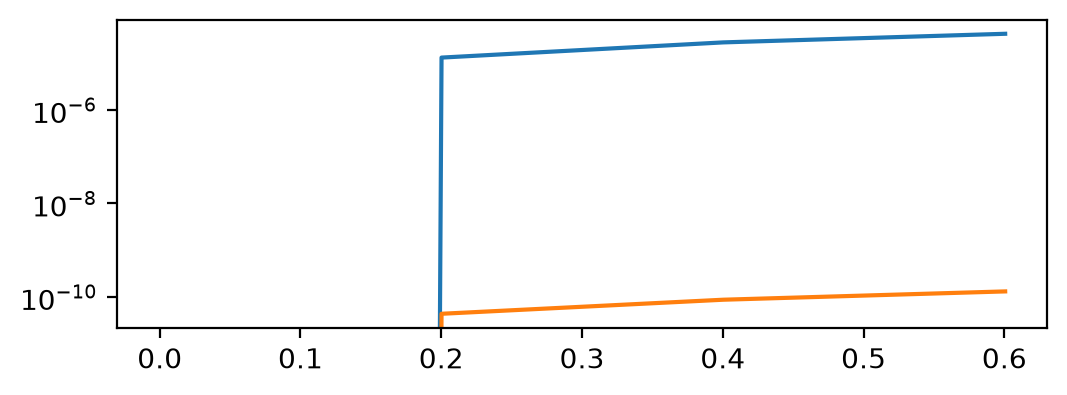

In [16]:
# Plot energy and enstrophy
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    # plt.plot(mysim['time'], mysim['enstrophy'])
    E = mysim['energy']
    Q = mysim['enstrophy']
    #T = mysim['trace']
    #N = mysim['normals']
    t = mysim['time']
    plt.semilogy(t, np.abs(E-E[0]))
    plt.semilogy(t, np.abs(Q-Q[0]))

##### Make video of simulation

In [17]:
qf.create_animation(filename.replace(".hdf5", ".mp4"), mysim['fun'],constraint_animation_args=constraint_animation_args)

100%|██████████| 4/4 [00:01<00:00,  3.74 frames/s]
